In [ ]:
import sys
from pathlib import Path

def find_repo_root_local(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "tools").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root.")

REPO_ROOT = find_repo_root_local(Path.cwd())
SRC_DIR = REPO_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import seaborn as sns
from experiment_utils import zscore
from plotly.subplots import make_subplots

STROKE_RESULTS_DIR = REPO_ROOT / "results" / "stroke"
save_path = STROKE_RESULTS_DIR / "segment_1_full_results.npz"

with np.load(save_path, allow_pickle=True) as data:
    hge_values = data['hge_values']
    hee_values = data['hee_values']
    sym_values = data['sym_values']
    hse_values = data['hse_values']
    pe_values = data['pe_values']
    coot_values = data['coot_values']
    ot_values = data['ot_values']
    gw_values = data['gw_values']
    models_alligned = data['models_alligned']
    pers_df_list = data['pers_df_list']
    couplings_s = data['couplings_s']
    couplings_f = data['couplings_f']


成功读取hge_values，形状： (50,)
成功读取m_sampled，形状： (600, 2)


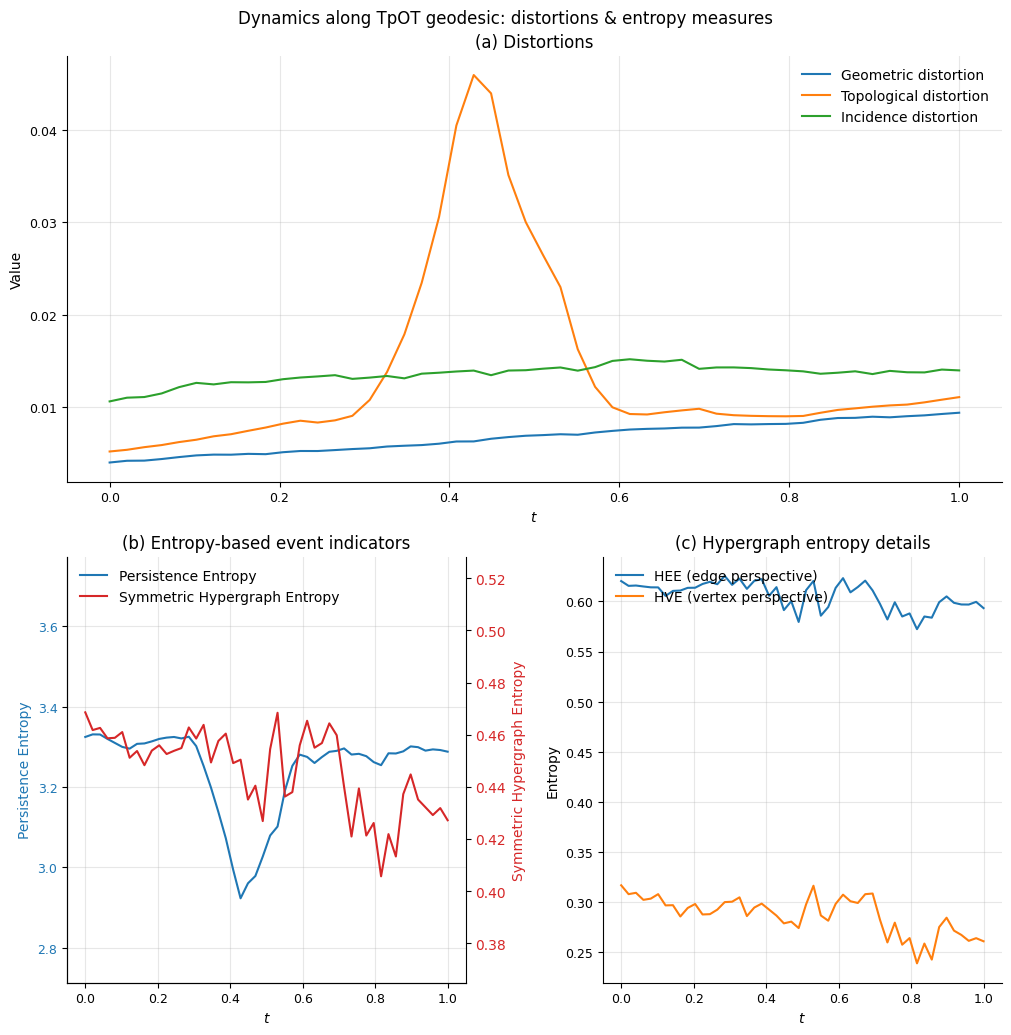

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

num_frames = len(coot_values)
x = np.arange(len(ot_values))

geom = np.asarray(gw_values)        # 几何（你原来的 gw_values / geom Values）
topo = np.asarray(ot_values)         # 拓扑
hyper = np.asarray(coot_values)      # 超图/Incidence（你原来 coot 或类似）

PE = np.asarray(pe_values)           # Persistence entropy
HE = np.asarray(hge_values)          # Hypergraph entropy
HEE = np.asarray(hee_values)         # Hyperedge-perspective entropy（或用 HEV）
SHE = np.asarray(sym_values)         # Symmetric hypergraph entropy
HSE = np.asarray(hse_values)

fig = plt.figure(figsize=(10, 10), constrained_layout=True)

gs = fig.add_gridspec(2, 2)

axA = fig.add_subplot(gs[0, :])

axB = fig.add_subplot(gs[1, 0])

axC = fig.add_subplot(gs[1, 1])

axA.plot(x/(num_frames-1), geom, label='Geometric distortion')
axA.plot(x/(num_frames-1), topo, label='Topological distortion')
axA.plot(x/(num_frames-1), hyper, label='Incidence distortion')
axA.set_title('(a) Distortions')
axA.set_xlabel(r'$t$')
axA.set_ylabel('Value')
axA.grid(True, alpha=0.3)
axA.legend(loc='upper right', ncol=1, frameon=False) # 图变宽了，Legend 放右上可能更好

color_left = 'tab:blue'
color_right = 'tab:red'

axB.plot(x/(num_frames-1), PE, color=color_left, label='Persistence Entropy')
axB.set_xlabel(r'$t$')
axB.set_ylabel('Persistence Entropy', color=color_left)
axB.tick_params(axis='y', labelcolor=color_left)
axB.grid(True, alpha=0.3)

axB_r = axB.twinx()
axB_r.plot(x/(num_frames-1), SHE, color=color_right, label='Symmetric Hypergraph Entropy')
axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
axB_r.tick_params(axis='y', labelcolor=color_right)

she_mean = np.nanmean(SHE)
she_range = np.nanmax(SHE) - np.nanmin(SHE)
pe_mean = np.nanmean(PE)
pe_range = np.nanmax(PE) - np.nanmin(PE)

if pe_range == 0: pe_range = 1.0
if she_range == 0: she_range = 1.0

axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

axB.set_title('(b) Entropy-based event indicators') # 序号顺延改为 (b)

lines, labels = axB.get_legend_handles_labels()
lines2, labels2 = axB_r.get_legend_handles_labels()
axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

axC.plot(x/(num_frames-1), HEE, label='HEE (edge perspective)')
axC.plot(x/(num_frames-1), HE, label='HVE (vertex perspective)')

axC.set_title('(c) Hypergraph entropy details') # 序号顺延改为 (c)
axC.set_xlabel(r'$t$')
axC.set_ylabel('Entropy')
axC.grid(True, alpha=0.3)
axC.legend(loc='upper left', ncol=1, frameon=False)

for ax in [axA, axB, axC]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax == axB:
        axB_r.spines['top'].set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=9)

fig.suptitle('Dynamics along TpOT geodesic: distortions & entropy measures', y=1.02)

plt.show()


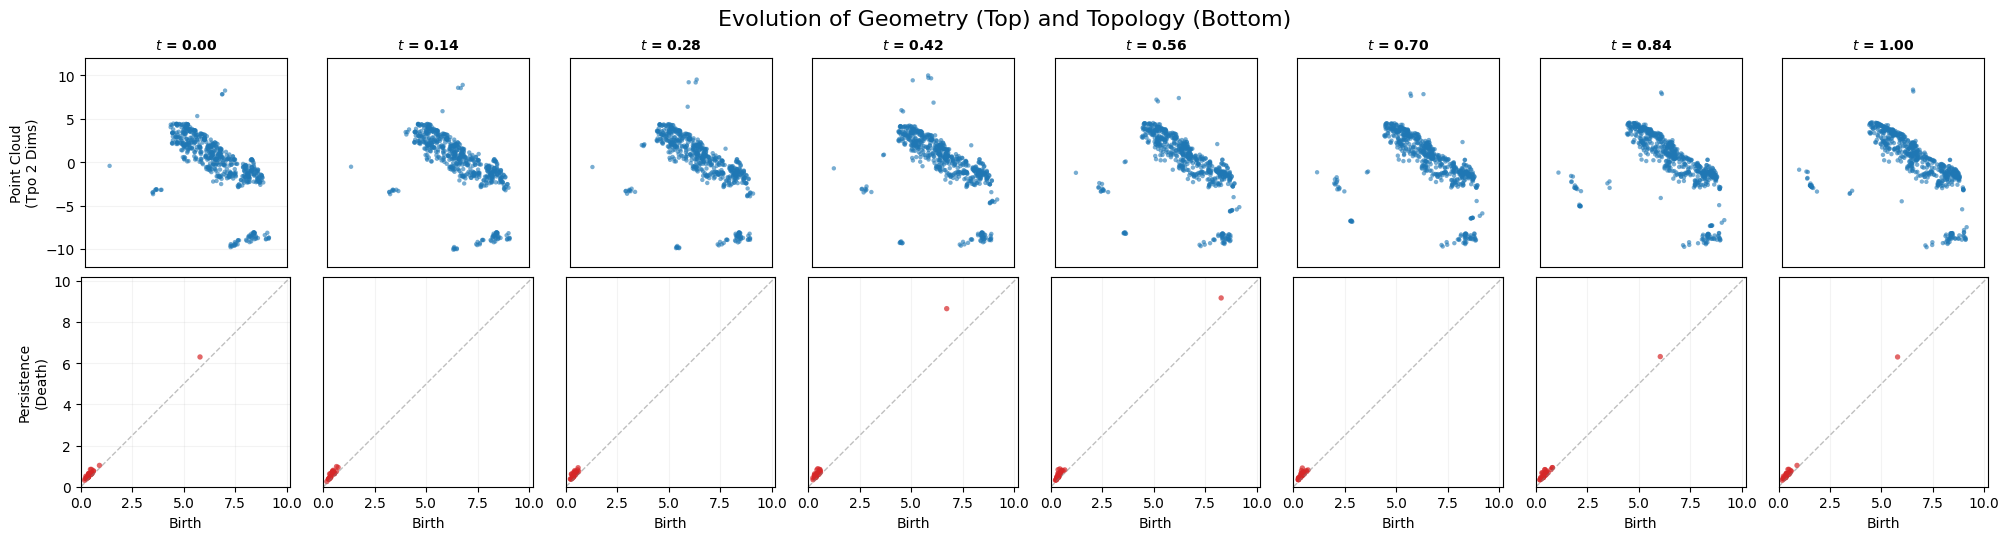

In [5]:
import numpy as np
import matplotlib.pyplot as plt

num_plots = 8  # 展示几列 (比如 8 个时间点)
total_frames = len(models_alligned)

indices = np.linspace(0, total_frames - 1, num_plots, dtype=int)

all_points_concat = np.vstack(models_alligned)
x_min, x_max = all_points_concat[:, 0].min(), all_points_concat[:, 0].max()
y_min, y_max = all_points_concat[:, 1].min(), all_points_concat[:, 1].max()

margin = 0.1
x_span = x_max - x_min
y_span = y_max - y_min
pc_xlim = (x_min - margin * x_span, x_max + margin * x_span)
pc_ylim = (y_min - margin * y_span, y_max + margin * y_span)

all_pd_concat = np.vstack([pd for pd in geodesic_pd if len(pd) > 0])
pd_max = np.max(all_pd_concat) * 1.1 if len(all_pd_concat) > 0 else 1.0
pd_lim = (0, pd_max)

fig, axes = plt.subplots(2, num_plots, figsize=(20, 5), constrained_layout=True)

for plot_idx, frame_idx in enumerate(indices):
    cloud = models_alligned[frame_idx]      # 形状 (N, 4)
    pd = geodesic_pd[frame_idx-1]    # 形状 (M, 2)
    t_val = frame_idx/(total_frames-1)

    ax_pc = axes[0, plot_idx]
    ax_pc.scatter(cloud[:, 0], cloud[:, 1], s=10, alpha=0.6, c='tab:blue', edgecolors='none')

    ax_pc.set_title(rf"$t$ = {t_val:.2f}", fontsize=10, fontweight='bold')
    ax_pc.set_xlim(pc_xlim)
    ax_pc.set_ylim(pc_ylim)
    ax_pc.set_aspect('equal')
    ax_pc.grid(True, alpha=0.15)

    ax_pd = axes[1, plot_idx]

    ax_pd.plot(pd_lim, pd_lim, c='gray', linestyle='--', linewidth=1, alpha=0.5)

    if len(pd) > 0:
        ax_pd.scatter(pd[:, 0], pd[:, 1], s=15, alpha=0.7, c='tab:red', edgecolors='none')

    ax_pd.set_xlim(pd_lim)
    ax_pd.set_ylim(pd_lim)
    ax_pd.set_aspect('equal')
    ax_pd.grid(True, alpha=0.15)

    if plot_idx == 0:
        ax_pc.set_ylabel("Point Cloud\n(Tpo 2 Dims)")
        ax_pd.set_ylabel("Persistence\n(Death)")
    else:
        ax_pc.set_yticks([])
        ax_pd.set_yticks([])

    ax_pc.set_xticks([])
    ax_pd.set_xlabel("Birth")

plt.suptitle("Evolution of Geometry (Top) and Topology (Bottom)", fontsize=16, y=1.05)
plt.show()


成功读取hge_values，形状： (50,)
成功读取m_sampled，形状： (600, 2)


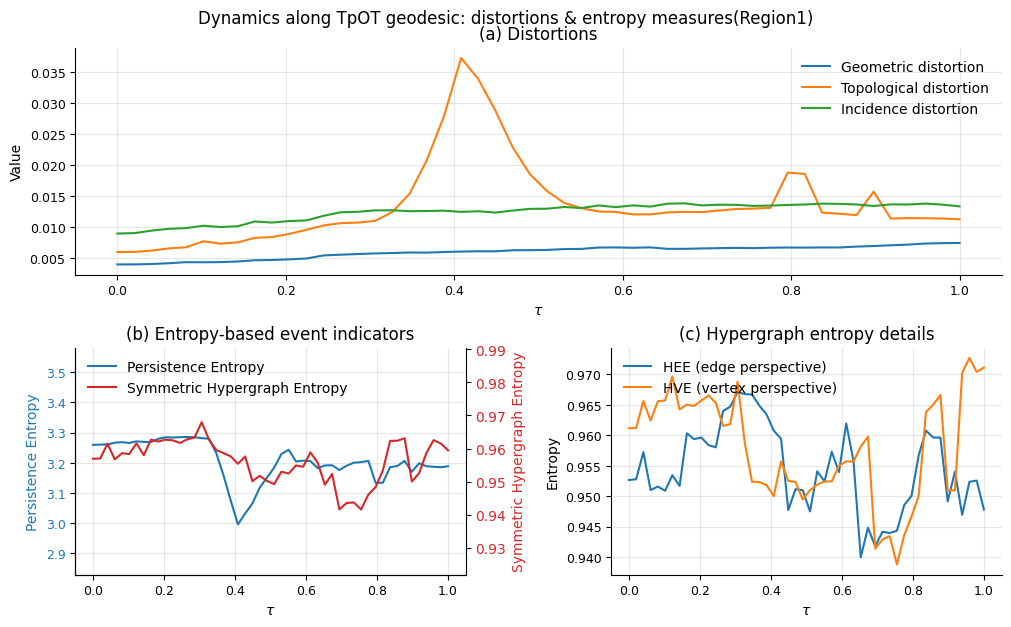

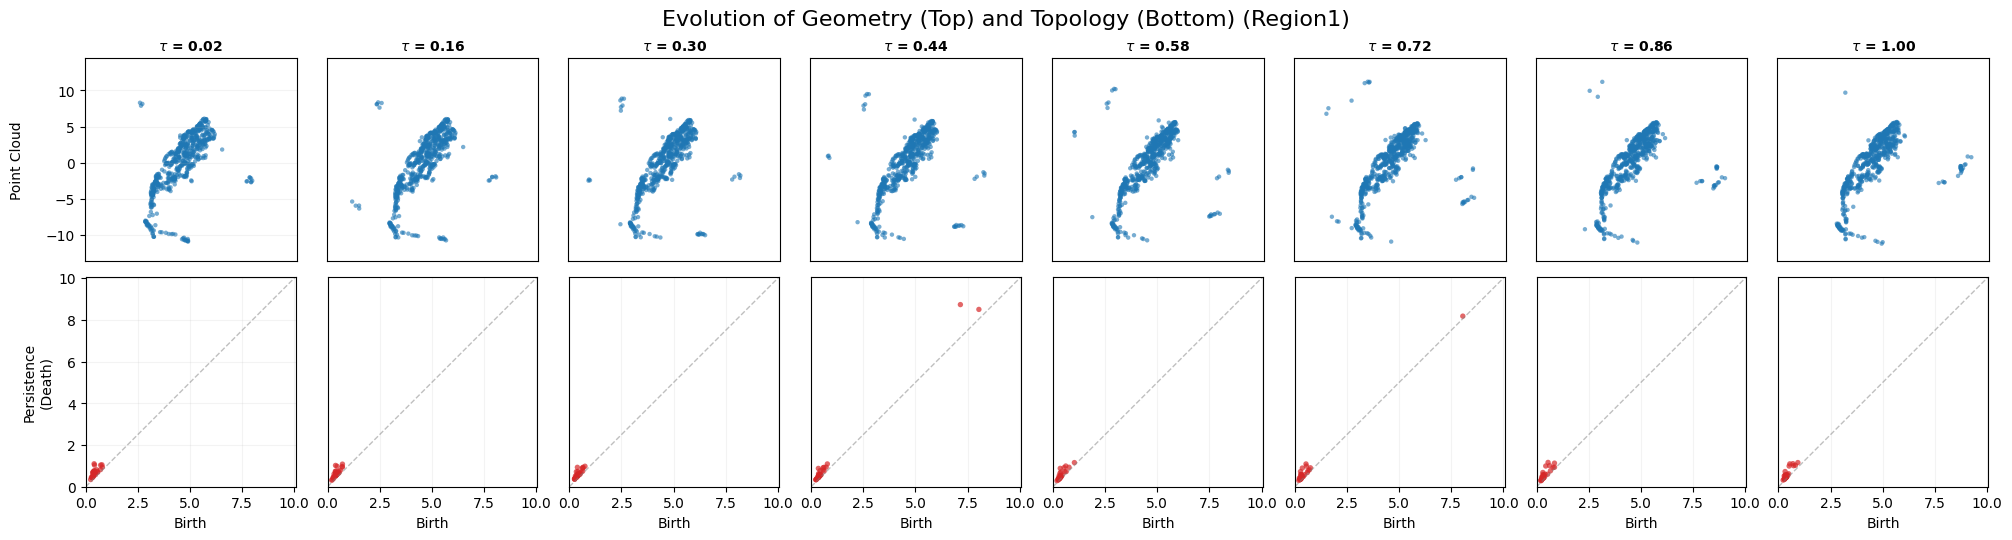

成功读取hge_values，形状： (50,)
成功读取m_sampled，形状： (600, 2)


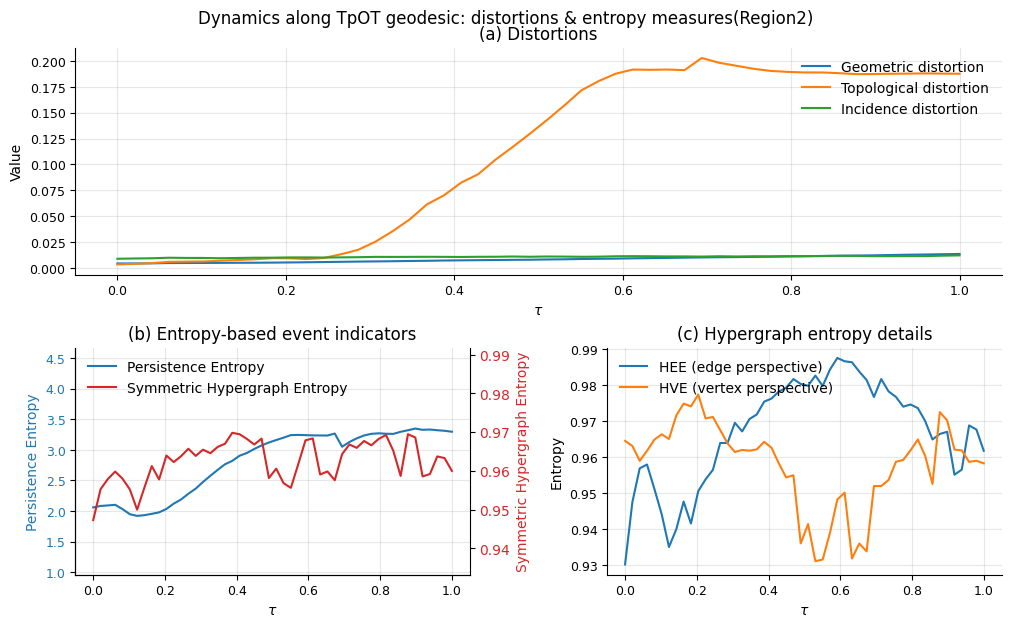

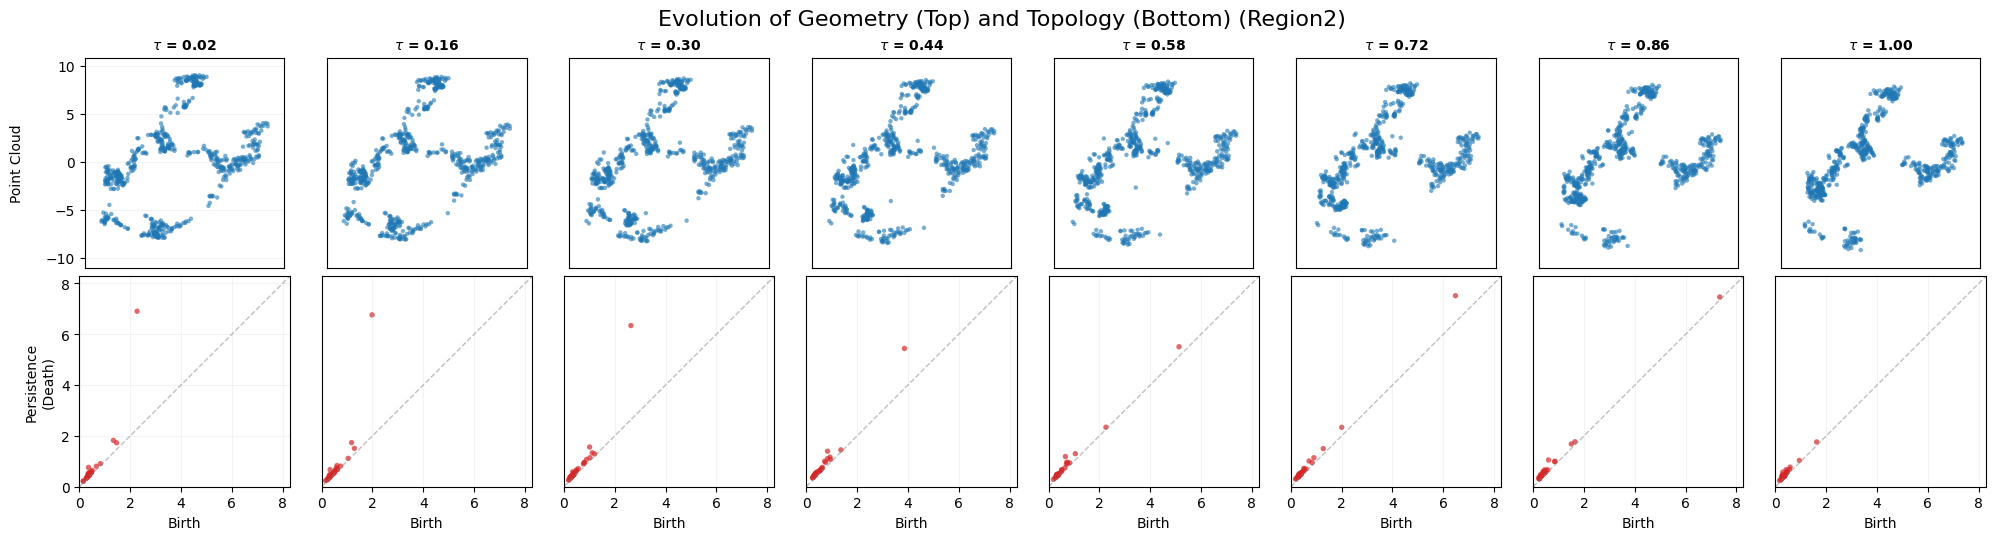

成功读取hge_values，形状： (50,)
成功读取m_sampled，形状： (600, 2)


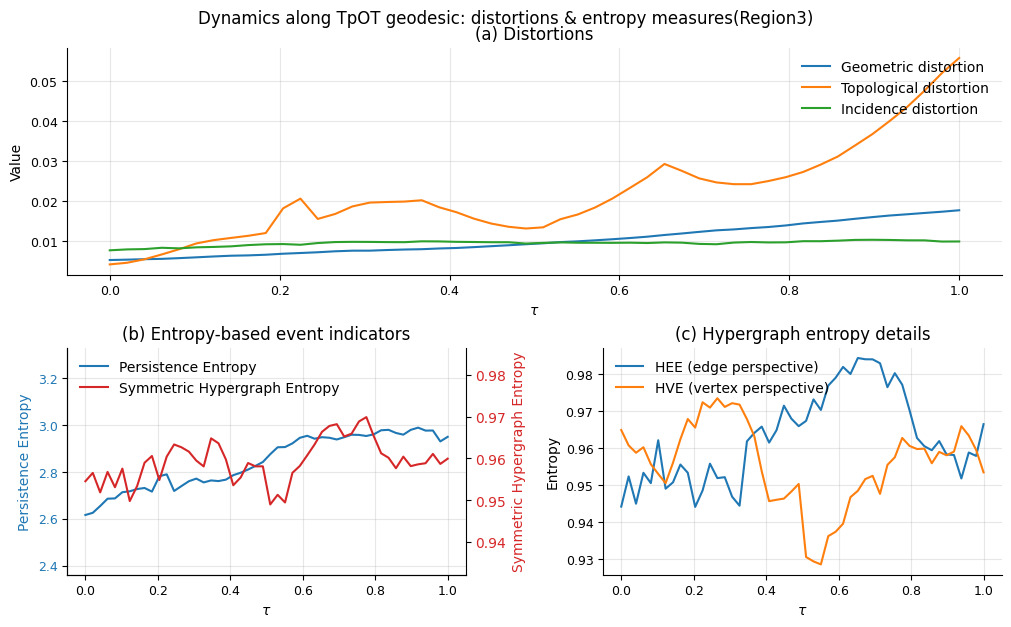

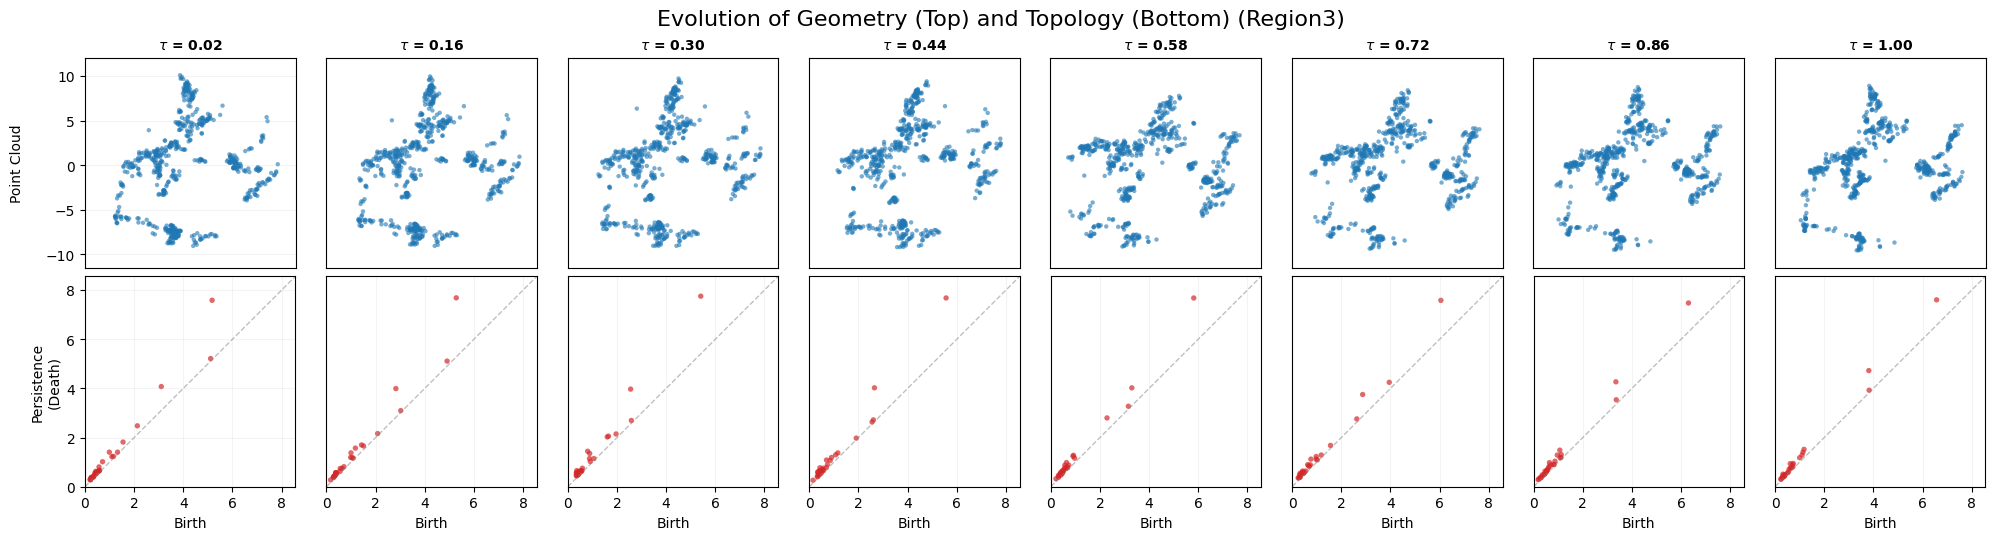

成功读取hge_values，形状： (50,)
成功读取m_sampled，形状： (600, 2)


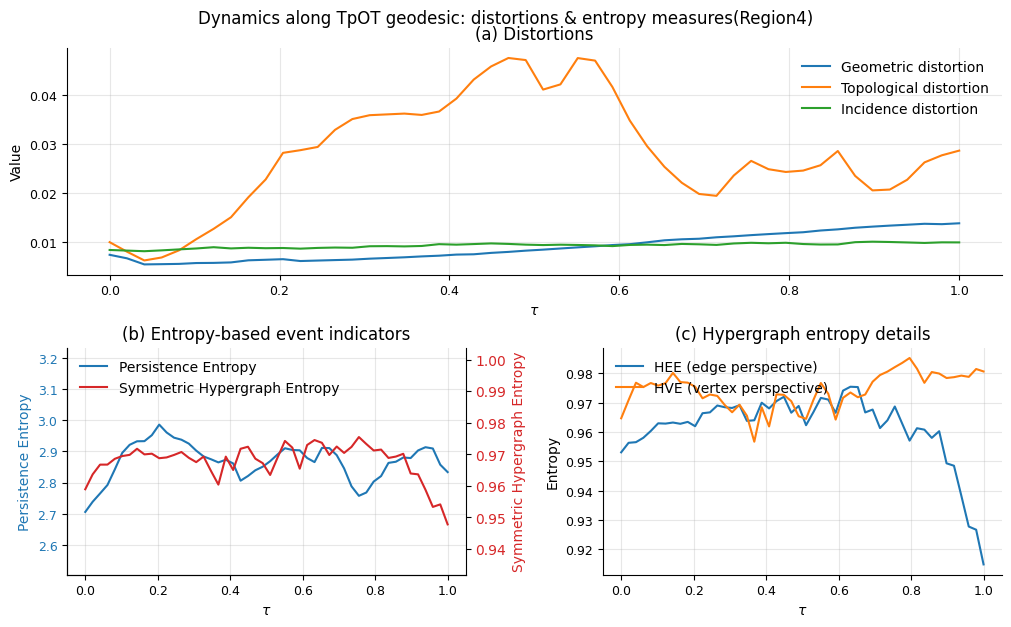

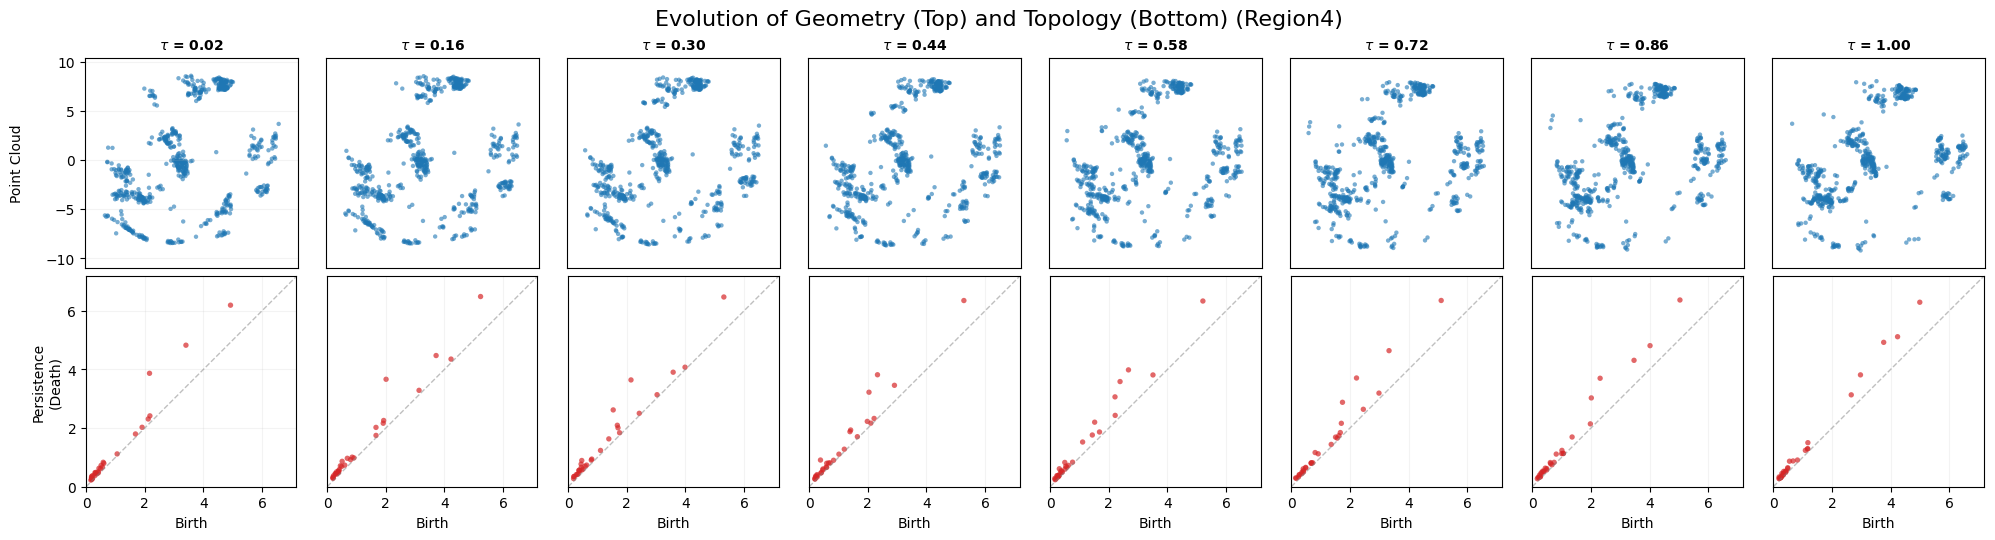

成功读取hge_values，形状： (50,)
成功读取m_sampled，形状： (600, 2)


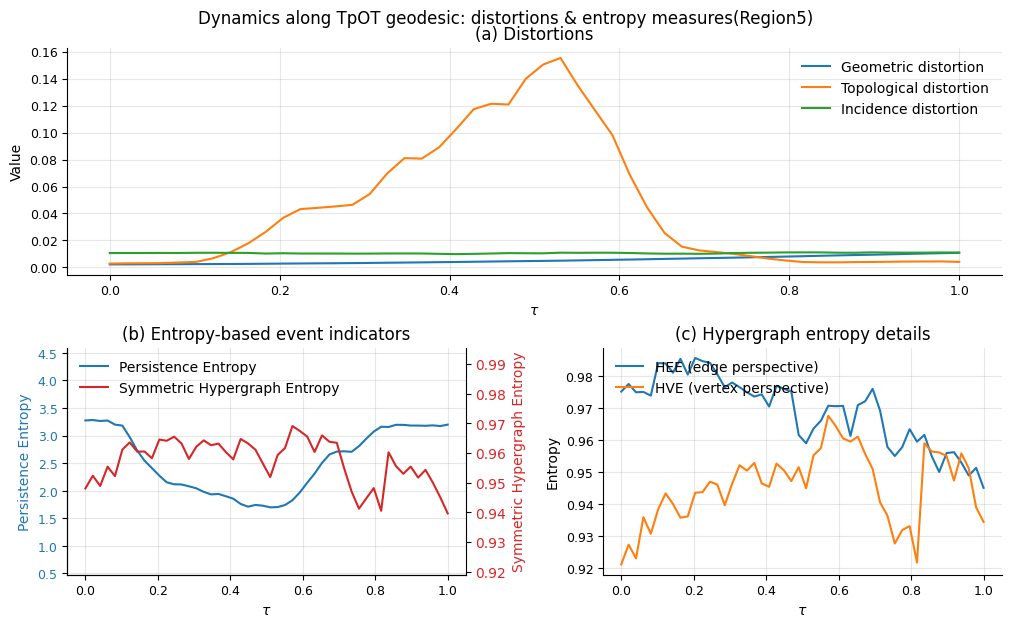

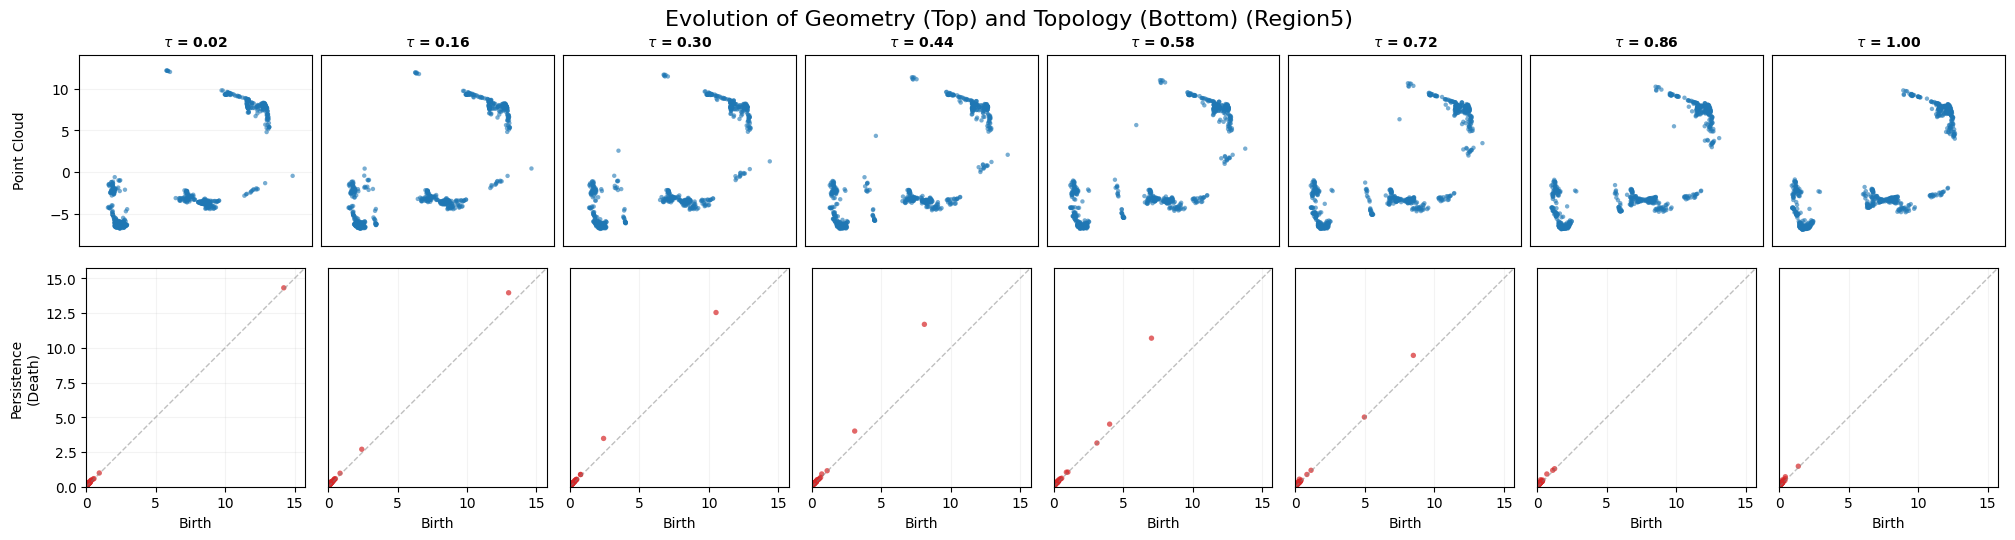

成功读取hge_values，形状： (50,)
成功读取m_sampled，形状： (600, 2)


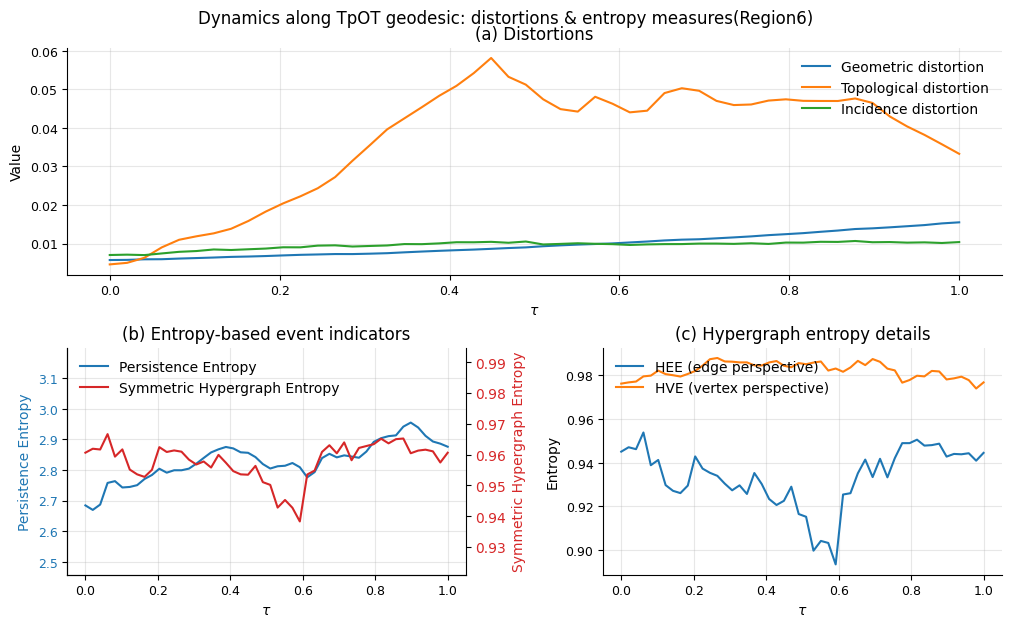

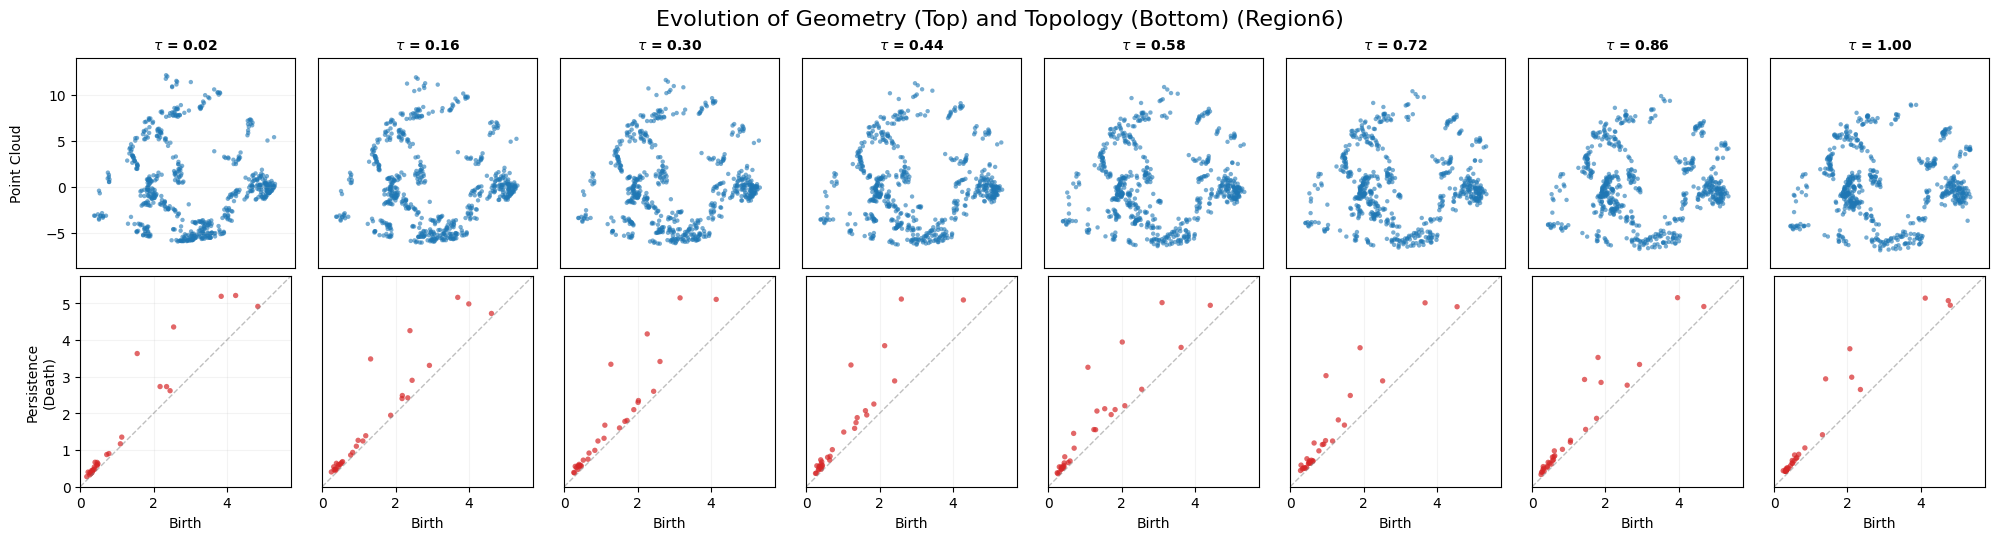

成功读取hge_values，形状： (50,)
成功读取m_sampled，形状： (600, 2)


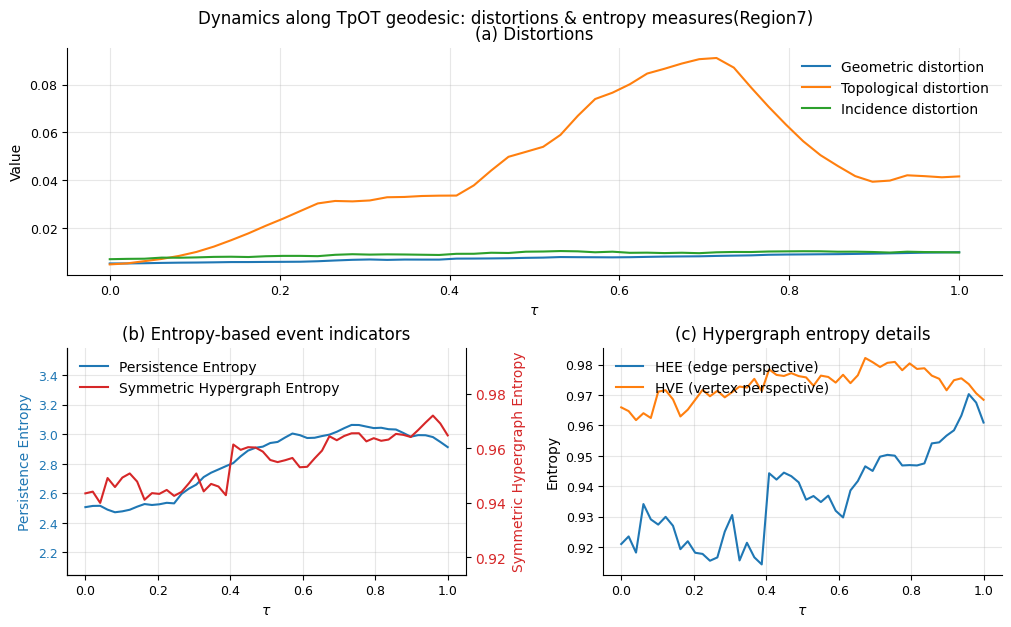

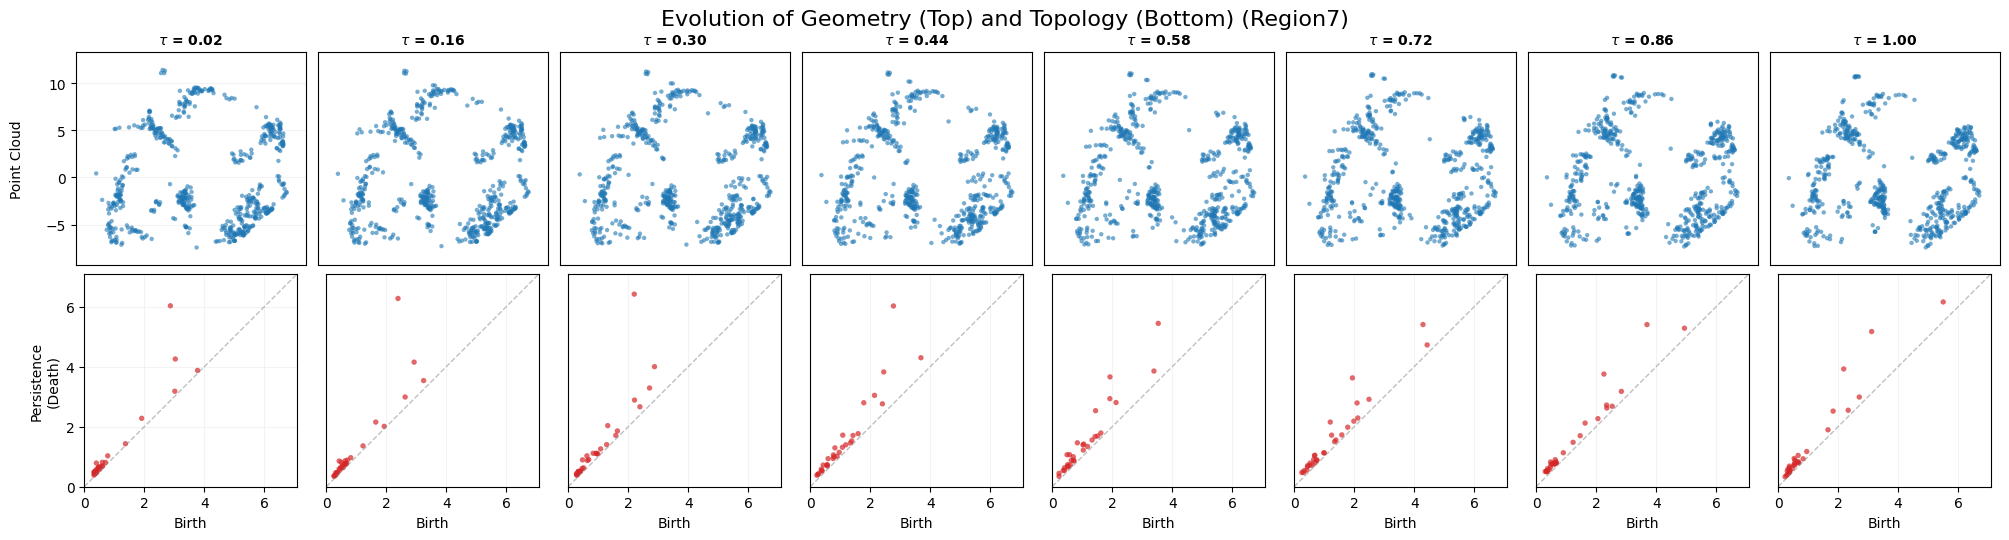

In [2]:
import numpy as np
yeo_sym_values = []
yeo_hge_values = []
yeo_hee_values = []
yeo_pe_values = []
yeo_coot_values = []
yeo_ot_values = []
yeo_gw_values = []
for i in range(1,8):
    save_path = STROKE_RESULTS_DIR / f"segment_{i}_full_results.npz"

    with np.load(save_path, allow_pickle=True) as data:
        hge_values = data['hge_values']       # 对应保存的hge_values
        hee_values = data['hee_values']       # 对应保存的hee_values
        sym_values = data['sym_values']       # 对应保存的sym_values
        hse_values = data['hse_values']       # 对应保存的hse_values
        pe_values = data['pe_values']        # 对应保存的pe_values

        yeo_sym_values.append(sym_values)
        yeo_hge_values.append(hge_values)
        yeo_hee_values.append(hee_values)
        yeo_pe_values.append(pe_values)

        coot_values = data['coot_values']    # 对应保存的coot_values
        ot_values = data['ot_values']        # 对应保存的ot_values
        gw_values = data['gw_values']        # 对应保存的gw_values

        yeo_coot_values.append(coot_values)
        yeo_ot_values.append(ot_values)
        yeo_gw_values.append(gw_values)

        models_alligned = data['models_alligned']  # 对应保存的models_alligned
        geodesic_pd = data['geodesic_pd']          # 对应保存的geodesic_pd

        geodesic_yt = data['geodesic_yt']          # 对应保存的geodesic_yt

        point_score_arr = data['point_score_abs']  # 对应保存的point_score_abs

        m_sampled = data['m_sampled']              # 对应保存的m_sampled
        y_sampled = data['y_sampled']              # 对应保存的y_sampled

    print("成功读取hge_values，形状：", hge_values.shape)
    print("成功读取m_sampled，形状：", m_sampled.shape)

    import numpy as np
    import matplotlib.pyplot as plt

    num_frames = len(coot_values)
    x = np.arange(len(ot_values))

    geom = np.asarray(gw_values)        # 几何（你原来的 gw_values / geom Values）
    topo = np.asarray(ot_values)         # 拓扑
    hyper = np.asarray(coot_values)      # 超图/Incidence（你原来 coot 或类似）

    PE = np.asarray(pe_values)           # Persistence entropy
    HE = np.asarray(hge_values)          # Hypergraph entropy
    HEE = np.asarray(hee_values)         # Hyperedge-perspective entropy（或用 HEV）
    SHE = np.asarray(sym_values)         # Symmetric hypergraph entropy
    HSE = np.asarray(hse_values)

    fig = plt.figure(figsize=(10, 6), constrained_layout=True)

    gs = fig.add_gridspec(2, 2)

    axA = fig.add_subplot(gs[0, :])

    axB = fig.add_subplot(gs[1, 0])

    axC = fig.add_subplot(gs[1, 1])

    axA.plot(x/(num_frames-1), geom, label='Geometric distortion')
    axA.plot(x/(num_frames-1), topo, label='Topological distortion')
    axA.plot(x/(num_frames-1), hyper, label='Incidence distortion')
    axA.set_title('(a) Distortions')
    axA.set_xlabel(r'$\tau$')
    axA.set_ylabel('Value')
    axA.grid(True, alpha=0.3)
    axA.legend(loc='upper right', ncol=1, frameon=False) # 图变宽了，Legend 放右上可能更好

    color_left = 'tab:blue'
    color_right = 'tab:red'

    axB.plot(x/(num_frames-1), PE, color=color_left, label='Persistence Entropy')
    axB.set_xlabel(r'$\tau$')
    axB.set_ylabel('Persistence Entropy', color=color_left)
    axB.tick_params(axis='y', labelcolor=color_left)
    axB.grid(True, alpha=0.3)

    axB_r = axB.twinx()
    axB_r.plot(x/(num_frames-1), SHE, color=color_right, label='Symmetric Hypergraph Entropy')
    axB_r.set_ylabel('Symmetric Hypergraph Entropy', color=color_right)
    axB_r.tick_params(axis='y', labelcolor=color_right)

    she_mean = np.nanmean(SHE)
    she_range = np.nanmax(SHE) - np.nanmin(SHE)
    pe_mean = np.nanmean(PE)
    pe_range = np.nanmax(PE) - np.nanmin(PE)

    if pe_range == 0: pe_range = 1.0
    if she_range == 0: she_range = 1.0

    axB.set_ylim(pe_mean - 1.3 * pe_range, pe_mean + 1.3 * pe_range)
    axB_r.set_ylim(she_mean - 1.3 * she_range, she_mean + 1.3 * she_range)

    axB.set_title('(b) Entropy-based event indicators') # 序号顺延改为 (b)

    lines, labels = axB.get_legend_handles_labels()
    lines2, labels2 = axB_r.get_legend_handles_labels()
    axB.legend(lines + lines2, labels + labels2, loc='upper left', frameon=False)

    axC.plot(x/(num_frames-1), HEE, label='HEE (edge perspective)')
    axC.plot(x/(num_frames-1), HE, label='HVE (vertex perspective)')

    axC.set_title('(c) Hypergraph entropy details') # 序号顺延改为 (c)
    axC.set_xlabel(r'$\tau$')
    axC.set_ylabel('Entropy')
    axC.grid(True, alpha=0.3)
    axC.legend(loc='upper left', ncol=1, frameon=False)

    for ax in [axA, axB, axC]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if ax == axB:
            axB_r.spines['top'].set_visible(False)

        ax.tick_params(axis='both', which='major', labelsize=9)

    fig.suptitle(f'Dynamics along TpOT geodesic: distortions & entropy measures(Region{i})', y=1.02)

    plt.show()

    import numpy as np
    import matplotlib.pyplot as plt

    num_plots = 8  # 展示几列 (比如 8 个时间点)
    total_frames = len(models_alligned)

    indices = np.linspace(1, total_frames - 1, num_plots, dtype=int)

    all_points_concat = np.vstack(models_alligned)
    x_min, x_max = all_points_concat[:, 0].min(), all_points_concat[:, 0].max()
    y_min, y_max = all_points_concat[:, 1].min(), all_points_concat[:, 1].max()

    margin = 0.1
    x_span = x_max - x_min
    y_span = y_max - y_min
    pc_xlim = (x_min - margin * x_span, x_max + margin * x_span)
    pc_ylim = (y_min - margin * y_span, y_max + margin * y_span)

    all_pd_concat = np.vstack([pd for pd in geodesic_pd if len(pd) > 0])
    pd_max = np.max(all_pd_concat) * 1.1 if len(all_pd_concat) > 0 else 1.0
    pd_lim = (0, pd_max)

    fig, axes = plt.subplots(2, num_plots, figsize=(20, 5), constrained_layout=True)

    for plot_idx, frame_idx in enumerate(indices):
        cloud = models_alligned[frame_idx-1]      # 形状 (N, 4)
        pd = geodesic_pd[frame_idx-1]    # 形状 (M, 2)
        t_val = frame_idx/(total_frames-1)

        ax_pc = axes[0, plot_idx]
        ax_pc.scatter(cloud[:, 0], cloud[:, 1], s=10, alpha=0.6, c='tab:blue', edgecolors='none')

        ax_pc.set_title(rf"$\tau$ = {t_val:.2f}", fontsize=10, fontweight='bold')
        ax_pc.set_xlim(pc_xlim)
        ax_pc.set_ylim(pc_ylim)
        ax_pc.set_aspect('equal')
        ax_pc.grid(True, alpha=0.15)

        ax_pd = axes[1, plot_idx]

        ax_pd.plot(pd_lim, pd_lim, c='gray', linestyle='--', linewidth=1, alpha=0.5)

        if len(pd) > 0:
            ax_pd.scatter(pd[:, 0], pd[:, 1], s=15, alpha=0.7, c='tab:red', edgecolors='none')

        ax_pd.set_xlim(pd_lim)
        ax_pd.set_ylim(pd_lim)
        ax_pd.set_aspect('equal')
        ax_pd.grid(True, alpha=0.15)

        if plot_idx == 0:
            ax_pc.set_ylabel("Point Cloud\n")
            ax_pd.set_ylabel("Persistence\n(Death)")
        else:
            ax_pc.set_yticks([])
            ax_pd.set_yticks([])

        ax_pc.set_xticks([])
        ax_pd.set_xlabel("Birth")

    plt.suptitle(f"Evolution of Geometry (Top) and Topology (Bottom) (Region{i})", fontsize=16, y=1.05)
    plt.show()


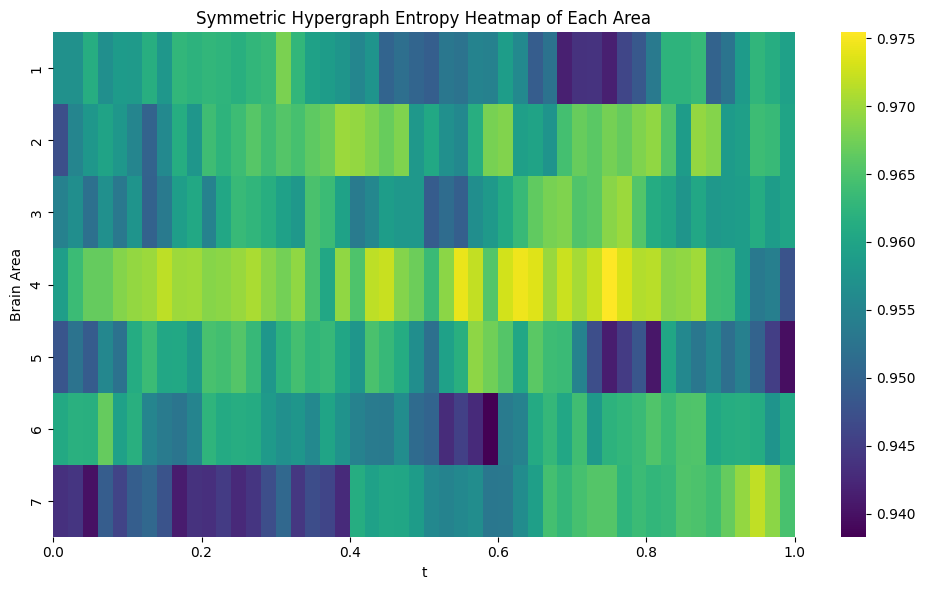

In [16]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = np.array(yeo_sym_values)

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap='viridis', annot=False)

num_cols = data.shape[1]
num_rows = data.shape[0]
xticks = np.linspace(0, num_cols, 6)             # 6个主刻度
xlabels = [f"{x:.1f}" for x in np.linspace(0, 1, 6)]
yticks = np.linspace(0.5, num_rows - 0.5, 7)
ylabels = [str(i) for i in range(1, 8)]
plt.xticks(xticks, xlabels)
plt.yticks(yticks, ylabels)
plt.title("Symmetric Hypergraph Entropy Heatmap of Each Area")
plt.xlabel("t")
plt.ylabel("Brain Area")
plt.tight_layout()
plt.show()


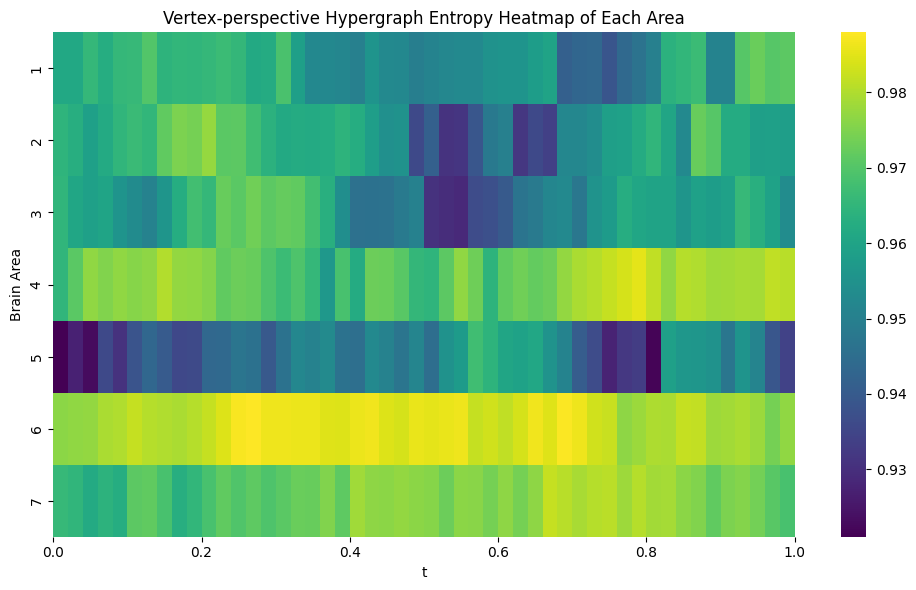

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = np.array(yeo_hge_values)

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap='viridis', annot=False)

num_cols = data.shape[1]
num_rows = data.shape[0]
xticks = np.linspace(0, num_cols, 6)             # 6个主刻度
xlabels = [f"{x:.1f}" for x in np.linspace(0, 1, 6)]
yticks = np.linspace(0.5, num_rows - 0.5, 7)
ylabels = [str(i) for i in range(1, 8)]
plt.xticks(xticks, xlabels)
plt.yticks(yticks, ylabels)
plt.title("Vertex-perspective Hypergraph Entropy Heatmap of Each Area")
plt.xlabel("t")
plt.ylabel("Brain Area")
plt.tight_layout()
plt.show()


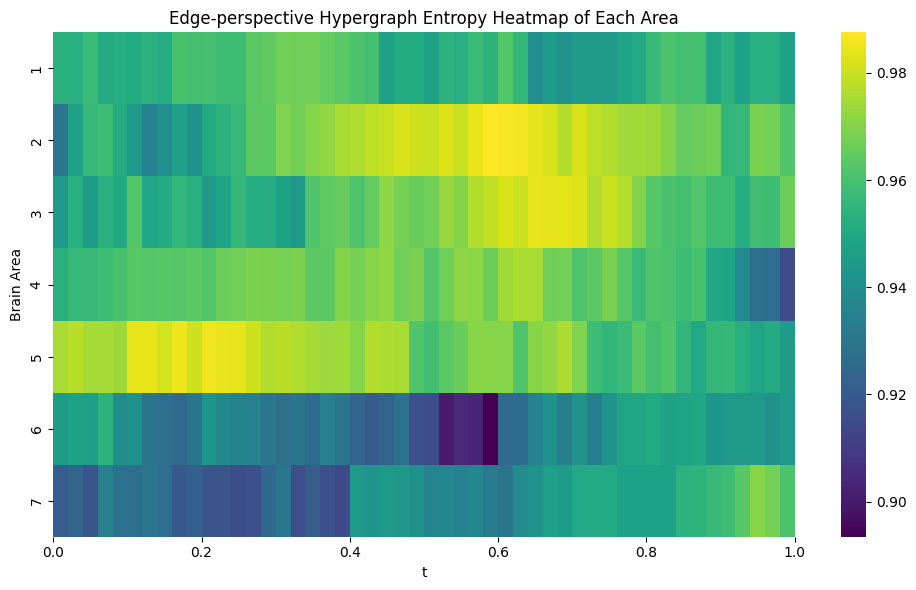

In [18]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = np.array(yeo_hee_values)

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap='viridis', annot=False)

num_cols = data.shape[1]
num_rows = data.shape[0]
xticks = np.linspace(0, num_cols, 6)             # 6个主刻度
xlabels = [f"{x:.1f}" for x in np.linspace(0, 1, 6)]
yticks = np.linspace(0.5, num_rows - 0.5, 7)
ylabels = [str(i) for i in range(1, 8)]
plt.xticks(xticks, xlabels)
plt.yticks(yticks, ylabels)
plt.title("Edge-perspective Hypergraph Entropy Heatmap of Each Area")
plt.xlabel("t")
plt.ylabel("Brain Area")
plt.tight_layout()
plt.show()


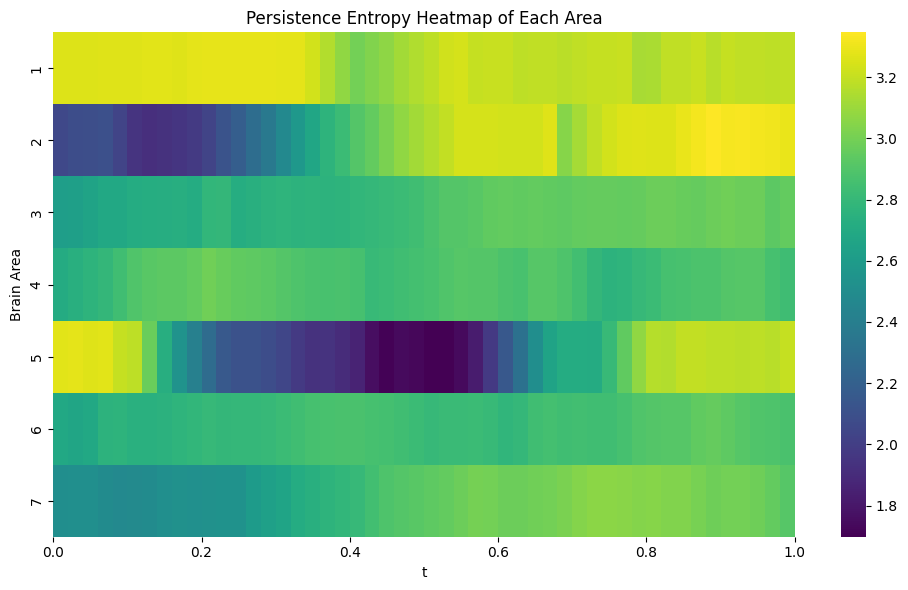

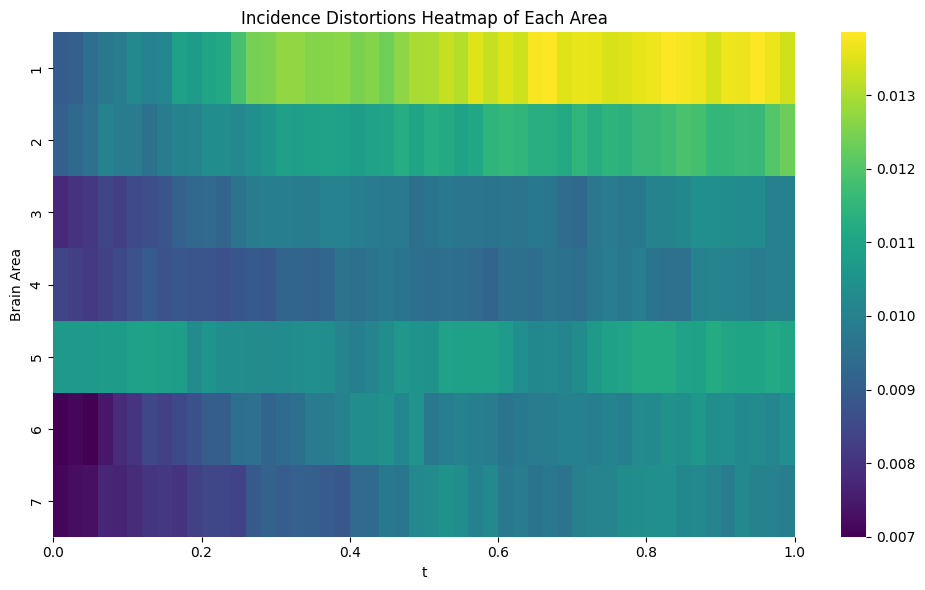

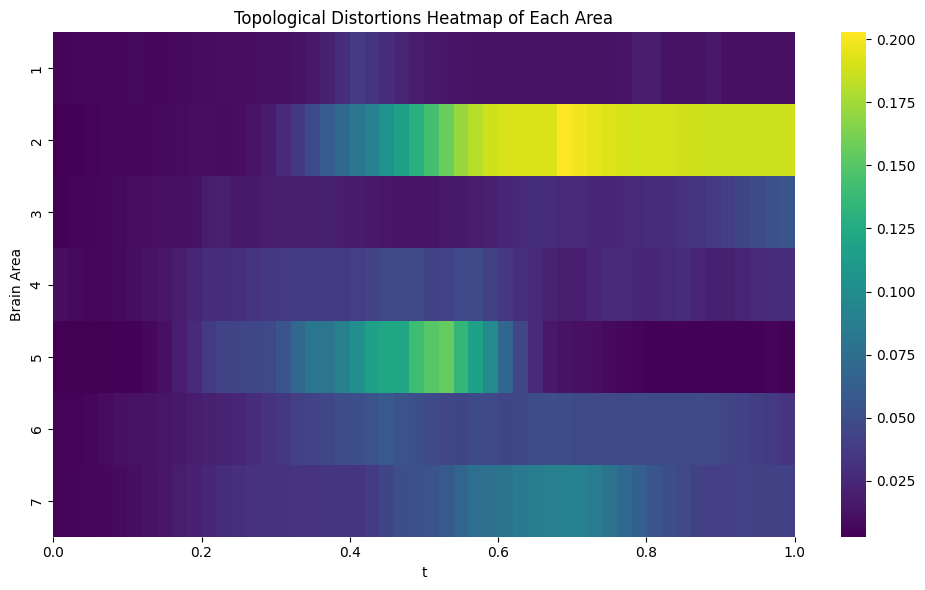

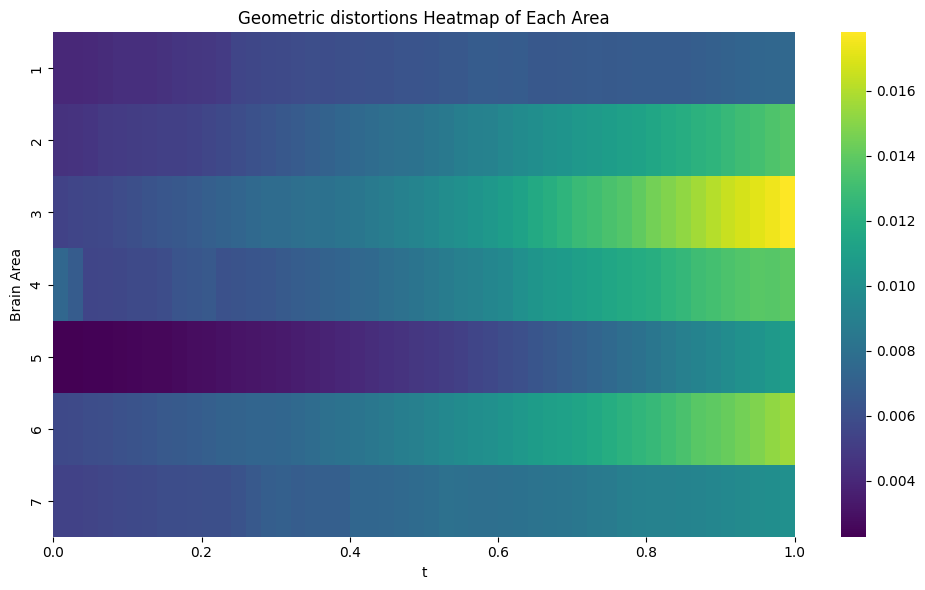

In [4]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = np.array(yeo_pe_values)

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap='viridis', annot=False)

num_cols = data.shape[1]
num_rows = data.shape[0]
xticks = np.linspace(0, num_cols, 6)             # 6个主刻度
xlabels = [f"{x:.1f}" for x in np.linspace(0, 1, 6)]
yticks = np.linspace(0.5, num_rows - 0.5, 7)
ylabels = [str(i) for i in range(1, 8)]
plt.xticks(xticks, xlabels)
plt.yticks(yticks, ylabels)
plt.title("Persistence Entropy Heatmap of Each Area")
plt.xlabel("t")
plt.ylabel("Brain Area")
plt.tight_layout()
plt.show()

data = np.array(yeo_coot_values)

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap='viridis', annot=False)

num_cols = data.shape[1]
num_rows = data.shape[0]
xticks = np.linspace(0, num_cols, 6)             # 6个主刻度
xlabels = [f"{x:.1f}" for x in np.linspace(0, 1, 6)]
yticks = np.linspace(0.5, num_rows - 0.5, 7)
ylabels = [str(i) for i in range(1, 8)]
plt.xticks(xticks, xlabels)
plt.yticks(yticks, ylabels)
plt.title("Incidence Distortions Heatmap of Each Area")
plt.xlabel("t")
plt.ylabel("Brain Area")
plt.tight_layout()
plt.show()

data = np.array(yeo_ot_values)

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap='viridis', annot=False)

num_cols = data.shape[1]
num_rows = data.shape[0]
xticks = np.linspace(0, num_cols, 6)             # 6个主刻度
xlabels = [f"{x:.1f}" for x in np.linspace(0, 1, 6)]
yticks = np.linspace(0.5, num_rows - 0.5, 7)
ylabels = [str(i) for i in range(1, 8)]
plt.xticks(xticks, xlabels)
plt.yticks(yticks, ylabels)
plt.title("Topological Distortions Heatmap of Each Area")
plt.xlabel("t")
plt.ylabel("Brain Area")
plt.tight_layout()
plt.show()

data = np.array(yeo_gw_values)

plt.figure(figsize=(10, 6))
sns.heatmap(data, cmap='viridis', annot=False)

num_cols = data.shape[1]
num_rows = data.shape[0]
xticks = np.linspace(0, num_cols, 6)             # 6个主刻度
xlabels = [f"{x:.1f}" for x in np.linspace(0, 1, 6)]
yticks = np.linspace(0.5, num_rows - 0.5, 7)
ylabels = [str(i) for i in range(1, 8)]
plt.xticks(xticks, xlabels)
plt.yticks(yticks, ylabels)
plt.title("Geometric distortions Heatmap of Each Area")
plt.xlabel("t")
plt.ylabel("Brain Area")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math

def plot_multi_frame_scores(npz_file_path):
    data = np.load(npz_file_path, allow_pickle=True)

    models_alligned = data['models_alligned']  # 形状: (num_frames, N, 2)
    point_score_abs = data['point_score_abs']  # 形状: (num_frames-1, N)

    num_total_frames = len(models_alligned)
    num_score_frames = len(point_score_abs)

    step = 10  # 你可以调整步长来决定显示多少个子图 (例如 10 意味着取大约 5-6 张图)
    indices = list(range(0, num_score_frames, step))
    if (num_score_frames - 1) not in indices:
        indices.append(num_score_frames - 1)

    rows = []
    for idx in indices:
        xy = np.asarray(models_alligned[idx + 1])
        sc = np.asarray(point_score_abs[idx]).astype(float)

        t_val = (idx + 1) / (num_total_frames - 1)

        rows.append(pd.DataFrame({
            "x": xy[:, 0],
            "y": xy[:, 1],
            "score": sc,
            "frame_idx": idx,
            "t_val": t_val
        }))
    DF = pd.concat(rows, ignore_index=True)

    vmin = np.percentile(DF["score"].values, 2)
    vmax = np.percentile(DF["score"].values, 100)
    if np.isclose(vmin, vmax):
        vmin, vmax = float(DF["score"].min()), float(DF["score"].max() + 1e-12)

    xmin, xmax = DF["x"].min(), DF["x"].max()
    ymin, ymax = DF["y"].min(), DF["y"].max()
    dx, dy = xmax - xmin, ymax - ymin
    pad_x, pad_y = 0.05 * dx, 0.05 * dy
    x_range = [xmin - pad_x, xmax + pad_x]
    y_range = [ymin - pad_y, ymax + pad_y]

    n_panels = len(indices)
    nrows = 2
    ncols = math.ceil(n_panels / nrows)

    titles = [f"t={df['t_val'].iloc[0]:.2f}" for _, df in DF.groupby("frame_idx", sort=False)]

    if len(titles) < nrows * ncols:
        titles.extend([""] * (nrows * ncols - len(titles)))

    fig = make_subplots(
        rows=nrows, cols=ncols,
        subplot_titles=titles,
        shared_xaxes=True, shared_yaxes=True,
        horizontal_spacing=0.03,
        vertical_spacing=0.12
    )

    coolwarm_scale = [
        [0.0, '#3b4cc0'], [0.1, '#5977e3'], [0.2, '#7b9ff9'], [0.3, '#9ebeff'],
        [0.4, '#c0d4f5'], [0.5, '#dddcdc'], [0.6, '#f2cbb7'], [0.7, '#f7ac8e'],
        [0.8, '#ee8468'], [0.9, '#d65244'], [1.0, '#b40426']
    ]

    for k, idx in enumerate(indices):
        row = k // ncols + 1
        col = k % ncols + 1

        df_i = DF[DF["frame_idx"] == idx]

        fig.add_trace(
            go.Scattergl(
                x=df_i["x"], y=df_i["y"],
                mode="markers",
                marker=dict(
                    size=5,
                    color=df_i["score"],
                    colorscale=coolwarm_scale,
                    cmin=vmin, cmax=vmax,
                    showscale=(row == 1 and col == ncols),
                    colorbar=dict(
                        title="|ΔHE|",
                        tickfont=dict(size=10),
                        ticks="outside",
                        tickformat=".4f"
                    )
                ),
                showlegend=False
            ),
            row=row, col=col
        )

        fig.update_xaxes(range=x_range, row=row, col=col)
        fig.update_yaxes(range=y_range, scaleanchor="x", scaleratio=1, row=row, col=col)

    fig.update_layout(
        width=max(350 * ncols, 900),
        height=360 * nrows,
        margin=dict(l=20, r=20, t=40, b=20),
        title_text="Dynamics of |ΔHE| along Geodesic",
        title_x=0.5,
        template="simple_white"
    )

    fig.show()

npz_path = '../../results/stroke/segment_5_full_results.npz'
plot_multi_frame_scores(npz_path)


In [70]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "browser"

def plot_single_frame_score(npz_file_path):
    data = np.load(npz_file_path, allow_pickle=True)

    models_alligned = data['models_alligned']
    point_score_abs = data['point_score_abs']

    final_coords = np.asarray(models_alligned[-1])
    final_score = np.asarray(point_score_abs[-1]).astype(float)

    vmin = np.percentile(final_score, 2)
    vmax = np.percentile(final_score, 100)
    if np.isclose(vmin, vmax):
        vmin, vmax = float(final_score.min()), float(final_score.max() + 1e-12)

    coolwarm_scale = [
        [0.0, '#3b4cc0'], [0.1, '#5977e3'], [0.2, '#7b9ff9'], [0.3, '#9ebeff'],
        [0.4, '#c0d4f5'], [0.5, '#dddcdc'], [0.6, '#f2cbb7'], [0.7, '#f7ac8e'],
        [0.8, '#ee8468'], [0.9, '#d65244'], [1.0, '#b40426']
    ]

    fig = go.Figure()

    fig.add_trace(
        go.Scattergl(
            x=final_coords[:, 0],
            y=final_coords[:, 1],
            mode="markers",
            marker=dict(
                size=6,
                color=final_score,
                colorscale=coolwarm_scale,
                cmin=vmin,
                cmax=vmax,
                showscale=True,
                colorbar=dict(
                    title="|ΔHE|",
                    tickfont=dict(size=12),
                    ticks="outside",
                    tickformat=".4f"
                )
            ),
            showlegend=False
        )
    )

    fig.update_layout(
        width=700,
        height=600,
        margin=dict(l=40, r=40, t=60, b=40),
        title_text= "$\\text{Point-level } |\\Delta \\text{HE}| \\text{ at } \\tau=1$ ",
        title_x=0.5,
        template="simple_white",
        xaxis=dict(title="UMAP x", scaleanchor="y", scaleratio=1),
        yaxis=dict(title="UMAP y")
    )

    fig.show()

npz_path = '../../results/stroke/segment_3_full_results.npz'
plot_single_frame_score(npz_path)
